# Grid recreations (point process on a grid)

Variant of `grid_continuation_point_process` whose purpose is **not** a fixed
continuation period nor a max-event cap, but **M independent recreations of
exactly N events** each.

Each recreation re-runs the grid point process from the forecast start and stops
as soon as **N** events have been generated. The RNG key differs per recreation:
it starts at **R** and increases to **R + M - 1**, so the M catalogs are
independent draws.

Heavy, seed-independent setup (Voronoi cells, Monte-Carlo spatial integrals,
per-cell background rate) is computed **once** and reused across all M
recreations.

This notebook mirrors helpers from **your** modules (`forecast_intensity`,
`data_utils`, `grid_simulation`, `utility_functions`). Only **upstream** `etas`
modules are imported (`inversion`, `mc_b_est`, ...).

## Configuration

Values match `config/pipeline_single_source_repo_grid_default.json` and the VS Code launch **MAGNET pipeline: grid only (500 events, density 1e-5)**.

In [1]:
from pathlib import Path

REPO_ROOT = Path("/a/home/cc/students/csguests/neriberman/Repos/etas")

# --- time windows (UTC strings, same as pipeline overrides.set_times) ---
AUXILIARY_START = "1971-01-01 00:00:00"
TIMEWINDOW_START = "1981-01-01 00:00:00"
TIMEWINDOW_END = "2007-01-01 00:00:00"  # forecast start (t0 for every recreation)
TESTWINDOW_END = "2021-01-01 00:00:00"

# --- catalog & region ---
CATALOG_PATH = REPO_ROOT / "input_data" / "example_catalog.csv"
SHAPE_COORDS_PATH = REPO_ROOT / "input_data" / "california_shape.npy"

# --- inversion metadata (template invert_etas_config.json + forced completeness) ---
MC = 3.6
DELTA_M = 0.1
COPPERSMITH_MULTIPLIER = 100
THETA_0 = {
    "log10_mu": -5.8,
    "log10_k0": -2.6,
    "a": 1.8,
    "log10_c": -2.5,
    "omega": -0.02,
    "log10_tau": 3.5,
    "log10_d": -0.85,
    "gamma": 1.3,
    "rho": 0.66,
}
INVERSION_OUTPUT_DIR = REPO_ROOT / "outputs" / "notebook_grid_continuation" / "inversions"
FORCE_INVERSION = False  # set True to re-run inversion even if cached
STORE_PIJ = True
STORE_DISTANCES = True
GOF_THRESHOLD = 1.0  # pipeline uses 1 for debugging

# --- grid recreations (M independent draws of N events each) ---
CONTINUATION_MODE = "grid"
N_EVENTS = 2            # events generated per recreation
M_RECREATIONS = 5000    # number of independent recreations
R_SEED_START = 1905     # RNG key for recreation i is R_SEED_START + i (i = 0 .. M-1)
GRID_POINT_DENSITY_KM2 = 5e-4
GRID_N_XY = (4, 4)      # used only when GRID_POINT_DENSITY_KM2 is None
MAGNITUDE_GENERATOR = "simulate_magnitudes"  # no MAGNET training in this launch config
KERNEL_VARIANT = "default"
PROGRESS_BAR = True

# --- shortcuts ---
# If True, skip simulation and load the saved recreation events CSV.
USE_SAVED_RECREATIONS = True
SAVED_RECREATIONS_PATH = None  # set to a path (str or Path) to override

# If SAVED_RECREATIONS_PATH is None, choose the most recently modified
# recreations_full_*.csv in RECREATIONS_OUTPUT_DIR.

# Saving behavior
SAVE_RECREATIONS_OUTPUT = True
FORCE_SAVE_RECREATIONS_WHEN_LOADING = False

# Prep cache (speeds up loading by skipping prepare_grid_inversion)
LOAD_SAVED_PREP = True
SAVE_PREP_OUTPUT = False
PREP_CACHE_SUFFIX = ".prep.pkl"  # stored next to recreations_full_*.csv

print("Configuration loaded:")
print(f"  catalog: {CATALOG_PATH}")
print(f"  shape:   {SHAPE_COORDS_PATH}")
print(f"  recreations: M={M_RECREATIONS} draws of N={N_EVENTS} events, "
      f"seeds {R_SEED_START}..{R_SEED_START + M_RECREATIONS - 1}")
print(f"  grid density: {GRID_POINT_DENSITY_KM2} pts/km², forecast start: {TIMEWINDOW_END}")


Configuration loaded:
  catalog: /a/home/cc/students/csguests/neriberman/Repos/etas/input_data/example_catalog.csv
  shape:   /a/home/cc/students/csguests/neriberman/Repos/etas/input_data/california_shape.npy
  recreations: M=5000 draws of N=2 events, seeds 1905..6904
  grid density: 0.0005 pts/km², forecast start: 2007-01-01 00:00:00


## Imports (upstream `etas` only)

In [2]:
import datetime as dt
import hashlib
import json
import logging
import os
import pickle
import pprint

# Must run before pyplot so figures embed in the notebook (Cursor / VS Code / Jupyter).
%matplotlib inline

import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.path as mpltPath
from IPython.display import display
import numpy as np
import pandas as pd
import tqdm
from scipy import integrate, optimize
from scipy import special
from scipy.optimize import root_scalar
from scipy.integrate import quad
from shapely import wkb
from shapely.geometry import Point, Polygon, MultiPoint
from shapely.prepared import prep
from shapely.ops import voronoi_diagram, transform

from etas.inversion import ETASParameterCalculation, polygon_surface
from etas import mc_b_est

try:
    import pyproj
except ImportError:
    pyproj = None

pp = pprint.PrettyPrinter(indent=2, width=100, sort_dicts=True)


def print_params(title, **kwargs):
    """Lightweight substitute for utility_functions.log_etas_params (no file I/O)."""
    print(f"\n=== {title} ===")
    for key, value in kwargs.items():
        if isinstance(value, dict):
            print(f"  {key}:")
            pp.pprint(value)
        else:
            print(f"  {key}: {value!r}")


2026-06-02 14:08:35.154374: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-06-02 14:08:35.188338: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-06-02 14:08:35.188374: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-06-02 14:08:35.189704: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-06-02 14:08:35.196094: I tensorflow/core/platform/cpu_feature_guar

## Copied helpers — `utility_functions` (spatial geometry)

In [3]:
EARTH_RADIUS_KM = 6.3781e3


def _hav(theta):
    return np.square(np.sin(theta / 2))


def haversine_km(lat_rad_1, lat_rad_2, lon_rad_1, lon_rad_2, earth_radius=EARTH_RADIUS_KM):
    return (
        2
        * earth_radius
        * np.arcsin(
            np.sqrt(
                _hav(lat_rad_1 - lat_rad_2)
                + np.cos(lat_rad_1) * np.cos(lat_rad_2) * _hav(lon_rad_1 - lon_rad_2)
            )
        )
    )


def km_per_degree_at_latitude(lat_deg, earth_radius=EARTH_RADIUS_KM):
    lat_rad = np.radians(np.asarray(lat_deg, dtype=float))
    km_per_lat = haversine_km(
        lat_rad - np.radians(0.5), lat_rad + np.radians(0.5), 0.0, 0.0, earth_radius
    )
    km_per_lon = haversine_km(lat_rad, lat_rad, 0.0, np.radians(1.0), earth_radius)
    if np.ndim(km_per_lat) == 0:
        return float(km_per_lat), float(km_per_lon)
    return km_per_lat, km_per_lon


def spatial_distance_squared_km2(lat_deg, lon_deg, lat_k_deg, lon_k_deg, earth_radius=EARTH_RADIUS_KM):
    lat_rad = np.radians(np.asarray(lat_deg, dtype=float))
    lon_rad = np.radians(np.asarray(lon_deg, dtype=float))
    lat_k_rad = np.radians(float(lat_k_deg))
    lon_k_rad = np.radians(float(lon_k_deg))
    return np.square(haversine_km(lat_k_rad, lat_rad, lon_k_rad, lon_rad, earth_radius))


## Copied helpers — `forecast_intensity`

In [4]:
GRID_DEFAULT_PARAMS = {
    "mu": 1e-7,
    "beta": np.log(10),
    "alpha": 1.9,
    "gamma": 1.3,
    "c": 10 ** (-2.2),
    "p": 1,
    "D": 0.5,
    "q": 1.5,
    "m0": 1,
}
KERNEL_VARIANT_DEFAULT = "default"
THETA_LOG10_TO_LINEAR = ("log10_mu", "log10_k0", "log10_c", "log10_tau", "log10_d")


def force_inversion_on_default_params(inversion_params, default_params=GRID_DEFAULT_PARAMS):
    inv = dict(inversion_params or {})
    inv_keys = set(inv.keys())
    params = default_params.copy()
    params.update(inv)
    for log_key in THETA_LOG10_TO_LINEAR:
        if log_key not in inv_keys or inv.get(log_key) is None:
            continue
        linear = log_key.replace("log10_", "", 1)
        if linear not in inv_keys:
            params[linear] = 10.0 ** float(inv[log_key])
    if "omega" in inv_keys and inv.get("omega") is not None:
        params["omega"] = float(inv["omega"])
        if "p" not in inv_keys:
            params["p"] = params["omega"] + 1.0
    elif "p" in inv_keys and inv.get("p") is not None and "omega" not in inv_keys:
        params["p"] = float(inv["p"])
        params["omega"] = params["p"] - 1.0
    if "rho" in inv_keys and inv.get("rho") is not None:
        params["rho"] = float(inv["rho"])
        if "q" not in inv_keys:
            params["q"] = float(inv["rho"]) + 1.0
    elif "q" in inv_keys and inv.get("q") is not None:
        params["q"] = float(inv["q"])
        if "rho" not in inv_keys:
            params["rho"] = float(inv["q"]) - 1.0
    else:
        params["rho"] = float(params.get("q", default_params["q"])) - 1.0
    if "D" not in inv_keys and params.get("d") is not None:
        params["D"] = float(params["d"]) ** 0.5
    return params


def _make_kernels_default(params):
    def mu(x, y):
        return params["mu"]

    def kappa(m, A=None):
        if A is None:
            A = params.get("k0")
            if A is None and "log10_k0" in params:
                A = np.power(10.0, params["log10_k0"])
            if A is None:
                A = 1.0
        a_eff = params.get("a", params.get("alpha", 0.0))
        return A * np.exp(a_eff * (m - params["m0"]))

    def g(t):
        t_arr = np.asarray(t, dtype=float)
        safe = np.maximum(t_arr, 0.0)
        val = np.exp(-safe / params["tau"]) / (safe + params["c"]) ** (1 + params["omega"])
        out = np.where(t_arr > 0, val, 0.0)
        if np.isscalar(t) or (hasattr(t, "shape") and t.shape == ()):
            return float(out)
        return out

    def G(t):
        return (
            (-np.exp(params["c"]/params["tau"]) * params["tau"]**(-params["omega"])
             ) * special.gammainc(-params["omega"], (params["c"] + t) / params["tau"])
        )

    def r(x, y, m):
        return (
            x**2 + y**2 + params["d"] * np.exp(params["gamma"] * (m - params["m0"]))
        ) ** (-(1 + params["rho"]))

    # def r(dist_sq_km2, m):
    #     return (
    #         dist_sq_km2 + params["d"] * np.exp(params["gamma"] * (m - params["m0"]))
    #     ) ** (-(1 + params["rho"]))

    def summand(dist_sq_km2, m, t):
        return kappa(m) * r(dist_sq_km2, m) * g(t)

    return {"mu": mu, "kappa": kappa, "g": g, "G": G, "f": r, "summand": summand}


def make_kernels(params=None, variant=KERNEL_VARIANT_DEFAULT):
    if params is None:
        params = GRID_DEFAULT_PARAMS.copy()
    v = variant.strip().lower() if isinstance(variant, str) else str(variant)
    if v == KERNEL_VARIANT_DEFAULT:
        return _make_kernels_default(params)
    raise ValueError(f"Unknown kernel variant {variant!r}")




def rate_at_t_all_grid(t_days, lat_flat, lon_flat, h_lat, h_lon, h_m, h_t_days, kernels=None):
    if kernels is None:
        kernels = make_kernels()
    kappa_fn = kernels["kappa"]
    g_fn = kernels["g"]
    f_fn = kernels["f"]
    mu_fn = kernels["mu"]
    n_grid = len(lat_flat)
    local_intensity = np.zeros(n_grid)
    for k in range(len(h_lat)):
        lat_k, lon_k, m_k, t_k_days = h_lat[k], h_lon[k], h_m[k], h_t_days[k]
        dt_days = t_days - t_k_days
        if dt_days <= 0:
            continue
        dist_sq = spatial_distance_squared_km2(lat_flat, lon_flat, lat_k, lon_k)
        local_intensity += kappa_fn(m_k) * f_fn(dist_sq, m_k) * g_fn(dt_days)
    mu_val = mu_fn(lat_flat[0], lon_flat[0])
    return mu_val + local_intensity


## Copied helpers — `data_utils`

In [5]:
def to_seconds(t):
    if hasattr(t, "timestamp"):
        return t.timestamp()
    return pd.Timestamp(t).timestamp()


def get_fallback_projection(lon, lat):
    if pyproj is None:
        raise ImportError("pyproj is required for get_fallback_projection")
    utm_crs_list = pyproj.database.query_utm_crs_info(
        datum_name="WGS 84",
        area_of_interest=pyproj.aoi.AreaOfInterest(
            west_lon_degree=float(lon),
            south_lat_degree=float(lat),
            east_lon_degree=float(lon) + 1e-5,
            north_lat_degree=float(lat) + 1e-5,
        ),
    )
    return pyproj.Proj(f"EPSG:{utm_crs_list[0].code}")


def latlon_rectangular_grid_in_polygon(
    polygon,
    grid_point_density_km2,
    *,
    earth_radius=EARTH_RADIUS_KM,
    rtol=0.05,
    max_iterations=40,
):
    if grid_point_density_km2 <= 0:
        raise ValueError("grid_point_density_km2 must be positive")
    area_km2 = float(polygon_surface(polygon))
    target_n = max(1, int(round(area_km2 * grid_point_density_km2)))
    min_lat, min_lon, max_lat, max_lon = polygon.bounds
    lat_c = 0.5 * (min_lat + max_lat)
    km_per_lat, km_per_lon = km_per_degree_at_latitude(lat_c, earth_radius)
    prep_poly = prep(polygon)
    spacing_km = float(np.sqrt(area_km2 / target_n))
    lat_flat = lon_flat = np.empty(0)
    n_lat = n_lon = 0
    for _ in range(max_iterations):
        spacing_lat = spacing_km / km_per_lat
        spacing_lon = spacing_km / km_per_lon
        n_lat = max(2, int(np.ceil((max_lat - min_lat) / spacing_lat)) + 1)
        n_lon = max(2, int(np.ceil((max_lon - min_lon) / spacing_lon)) + 1)
        lats = np.linspace(min_lat, max_lat, n_lat)
        lons = np.linspace(min_lon, max_lon, n_lon)
        lat_mesh, lon_mesh = np.meshgrid(lats, lons)
        lat_cand = lat_mesh.ravel()
        lon_cand = lon_mesh.ravel()
        inside = np.fromiter(
            (prep_poly.contains(Point(lat, lon)) for lat, lon in zip(lat_cand, lon_cand)),
            dtype=bool,
            count=lat_cand.size,
        )
        n_inside = int(inside.sum())
        if n_inside == 0:
            spacing_km *= 0.5
            continue
        lat_flat = lat_cand[inside]
        lon_flat = lon_cand[inside]
        if abs(n_inside - target_n) / target_n <= rtol:
            break
        spacing_km *= np.sqrt(n_inside / target_n)
    if lat_flat.size == 0:
        raise RuntimeError("Could not place any grid nodes inside the polygon")
    info = {
        "area_km2": area_km2,
        "target_n": target_n,
        "n_points": int(lat_flat.size),
        "spacing_km": spacing_km,
        "grid_n_xy": (n_lat, n_lon),
        "grid_point_density_km2": float(grid_point_density_km2),
    }
    return lat_flat, lon_flat, info


def estimate_area_km2_from_latlon_grid(lat_flat, lon_flat, earth_radius=EARTH_RADIUS_KM):
    lat_flat = np.asarray(lat_flat, dtype=float)
    lon_flat = np.asarray(lon_flat, dtype=float)
    unique_lat = np.unique(lat_flat)
    unique_lon = np.unique(lon_flat)
    if len(unique_lat) > 1 and len(unique_lon) > 1:
        dlat = float(np.mean(np.diff(np.sort(unique_lat))))
        dlon = float(np.mean(np.diff(np.sort(unique_lon))))
        mean_lat = float(np.mean(lat_flat))
        km_per_lat, km_per_lon = km_per_degree_at_latitude(mean_lat, earth_radius)
        cell_km2 = (dlat * km_per_lat) * (dlon * km_per_lon)
        return cell_km2 * len(lat_flat)
    km_per_lat, km_per_lon = km_per_degree_at_latitude(float(np.mean(lat_flat)), earth_radius)
    span_lat = float(lat_flat.max() - lat_flat.min())
    span_lon = float(lon_flat.max() - lon_flat.min())
    return max(span_lat * km_per_lat * span_lon * km_per_lon, 1e-12)


## Grid point process — seed-independent setup + N-event sampler

`prepare_grid_inversion` does the expensive, seed-independent work once (Voronoi
cells, Monte-Carlo spatial integrals over the history, per-cell background rate).
`generate_n_events` then draws **exactly N** events via Ogata-style compensator
inversion, with **no time cap** — it loops until N events are produced. Calling
it M times with different seeds yields M independent recreations.

In [6]:
def _swap_xy(x, y):
    return y, x

def get_ordered_voronoi_cells(polygon_latlon, lat_flat, lon_flat):
    # Swap bounding polygon to standard (lon, lat)
    polygon_lonlat = transform(_swap_xy, polygon_latlon)
    
    # Create ordered points
    points = [Point(lon, lat) for lon, lat in zip(lon_flat, lat_flat)]
    
    # Generate raw Voronoi diagram
    vd = voronoi_diagram(MultiPoint(points), envelope=polygon_lonlat)
    raw_cells = list(vd.geoms)
    
    # Use spatial join to map the unordered cells back to the exact order of input points
    points_gdf = gpd.GeoDataFrame(geometry=points)
    cells_gdf = gpd.GeoDataFrame(geometry=raw_cells)
    
    matched = points_gdf.sjoin(cells_gdf, how="left", predicate="intersects")
    matched = matched[~matched.index.duplicated(keep='first')]
    
    ordered_clipped_cells = []
    
    for idx in matched['index_right'].values:
        if np.isnan(idx):
            # Point is completely orphaned/outside
            ordered_clipped_cells.append(Polygon()) 
        else:
            # Extract matched cell and clip it to the overarching polygon boundary
            cell = raw_cells[int(idx)]
            clipped_cell = cell.intersection(polygon_lonlat)
            ordered_clipped_cells.append(clipped_cell)
            
    return ordered_clipped_cells


def monte_carlo_polygon_integral(polygon, r_func, x_i, y_i, m_i, num_points=10000):
    # 1. Get bounding box
    min_lon, min_lat, max_lon, max_lat = polygon.bounds
    
    # 2. Generate random points within the bounding box
    x_rand = np.random.uniform(min_lon, max_lon, num_points)
    y_rand = np.random.uniform(min_lat, max_lat, num_points)
    points = np.column_stack((x_rand, y_rand))
    
    # 3. Fast vectorized check for points inside the polygon using matplotlib
    # Extract exterior coordinates of the Shapely polygon
    poly_path = mpltPath.Path(list(polygon.exterior.coords))
    inside_mask = poly_path.contains_points(points)
    
    # Filter points inside
    x_inside = x_rand[inside_mask]
    y_inside = y_rand[inside_mask]
    
    if len(x_inside) == 0:
        return 0.0
        
    # 4. Evaluate the function on the valid points
    # This is entirely vectorized and can be pushed to a GPU if using PyTorch/CuPy
    f_values = r_func(x_inside - x_i, y_inside - y_i, m_i)
    
    # 5. Calculate integral: (Average value of f) * (Area of the bounding box) * (ratio of points inside)
    # Equivalently: Average of f inside * Area of Polygon
    mean_f = np.mean(f_values)
    
    return mean_f * polygon.area


def calculate_areas_km2(polygons):
    geod = pyproj.Geod(ellps="WGS84")
    areas = []
    
    for poly in polygons:
        if poly.is_empty:
            # Handle orphaned points that returned an empty Polygon()
            areas.append(0.0)
        else:
            # geometry_area_perimeter calculates exact geodesic area on the ellipsoid
            area_m2, _ = geod.geometry_area_perimeter(poly)
            areas.append(abs(area_m2) / 1e6)
            
    return areas


def omori_for_all_previous_events(current_time_days, working_history, kernels):
    t_i = working_history["time"].values / SECONDS_PER_DAY
    return kernels["g"](current_time_days - t_i).ravel()





In [7]:
SECONDS_PER_DAY = 86400.0


def prepare_grid_inversion(
    history,
    lat_flat,
    lon_flat,
    params,
    *,
    kernel_variant=KERNEL_VARIANT_DEFAULT,
    area_km2=None,
    polygon=None,
    progress_bar=False,
):
    """Seed-independent setup shared by every recreation.

    Builds the kernels, Voronoi cells, per-cell background rate and the history
    spatio-magnitude weight matrix once, so each recreation only pays for the
    cheap compensator-sampling loop in ``generate_n_events``.

    ``progress_bar``: if True, show a tqdm bar over grid cells while filling
    the spatio-magnitude weight matrix.
    """
    kernels = make_kernels(params, variant=kernel_variant)
    working_history = history.copy() if isinstance(history, pd.DataFrame) else pd.DataFrame(history)
    n_grid = len(lat_flat)

    mu_density = float(kernels["mu"](lat_flat[0], lon_flat[0]))
    if area_km2 is None:
        area_km2 = estimate_area_km2_from_latlon_grid(lat_flat, lon_flat)
    area_km2 = float(area_km2)

    ordered_cells = get_ordered_voronoi_cells(polygon, lat_flat, lon_flat)
    n_hist = len(working_history)
    r_spatial_integral = np.empty((n_grid, n_hist))
    p_m = np.empty((n_grid, n_hist))
    grid_iter = (
        tqdm.tqdm(range(n_grid), desc="prepare_grid_inversion", unit="cell")
        if progress_bar
        else range(n_grid)
    )
    for j in grid_iter:
        for i in range(n_hist):
            r_spatial_integral[j, i] = monte_carlo_polygon_integral(
                ordered_cells[j], kernels["f"], lon_flat[j], lat_flat[j],
                working_history["magnitude"].iloc[i],
            )
            p_m[j, i] = kernels["kappa"](working_history["magnitude"].iloc[i])
    spatio_mag_part_base = r_spatial_integral * p_m

    areas_array = np.array(calculate_areas_km2(ordered_cells))
    mu_per_cell = mu_density * areas_array

    print_params(
        "prepare_grid_inversion",
        params=params,
        n_grid_points=n_grid,
        n_history=n_hist,
        kernel_variant=kernel_variant,
        area_km2=area_km2,
        mu_density=mu_density,
    )

    return {
        "kernels": kernels,
        "history_base": working_history,
        "spatio_mag_part_base": spatio_mag_part_base,
        "ordered_cells": ordered_cells,
        "mu_per_cell": mu_per_cell,
        "lat_flat": np.asarray(lat_flat),
        "lon_flat": np.asarray(lon_flat),
        "n_grid": n_grid,
        "params": params,
    }


def generate_n_events(prep, start_forecast, n_events, *, seed=None):
    """Draw exactly ``n_events`` events from the grid point process.

    Starts from ``start_forecast`` (seconds) using the shared setup in ``prep``.
    There is NO time cap: the loop runs until ``n_events`` events are produced.
    ``seed`` sets ``np.random.seed`` so each recreation is an independent draw.
    Returns only the freshly generated events (history excluded).
    """
    if seed is not None:
        np.random.seed(seed)

    kernels = prep["kernels"]
    lat_flat = prep["lat_flat"]
    lon_flat = prep["lon_flat"]
    n_grid = prep["n_grid"]
    params = prep["params"]
    mu_per_cell = prep["mu_per_cell"]
    ordered_cells = prep["ordered_cells"]

    working_history = prep["history_base"].copy()
    n_past = len(working_history)
    spatio_mag_part = prep["spatio_mag_part_base"].copy()

    magnitude_generator = mc_b_est.simulate_magnitudes
    q_derivative = kernels["g"]
    G_integrated = kernels["G"]

    t = float(start_forecast)
    events_generated = 0
    while events_generated < n_events:
        t_days = t / SECONDS_PER_DAY
        h_t_days = working_history["time"].values / SECONDS_PER_DAY

        # Array to store the simulated next event time for every single cell
        t_next_cells = np.full(n_grid, np.inf)
        w_start = t_days - h_t_days
        G_start = G_integrated(w_start)

        # Solve the exact compensator equation for EVERY cell independently
        for j in range(n_grid):
            target_j = -np.log(np.random.uniform(0, 1))
            mu_j = mu_per_cell[j]
            weights_j = spatio_mag_part[j, :]

            def F_j(t_prime_days):
                term1 = mu_j * (t_prime_days - t_days)
                w_end = t_prime_days - h_t_days
                integral_diffs = G_integrated(w_end) - G_start
                term2 = np.sum(weights_j * integral_diffs)
                return term1 + term2 - target_j

            def F_prime_j(t_prime_days):
                w_prime = t_prime_days - h_t_days
                q_vals = q_derivative(w_prime)
                return mu_j + np.sum(weights_j * q_vals)

            if mu_j > 1e-12:
                t_upper = t_days + (target_j / mu_j)
            else:
                t_upper = t_days + 1000.0  # arbitrary forward step if background ~ 0

            max_expansions = 20
            expansions = 0
            while F_j(t_upper) < 0 and expansions < max_expansions:
                t_upper += (t_upper - t_days) * 2
                expansions += 1

            if F_j(t_upper) < 0:
                # Cell never fires again in finite time.
                t_next_cells[j] = np.inf
                continue

            sol = root_scalar(F_j, bracket=[t_days, t_upper], method="brentq", xtol=1e-4)
            if not sol.converged:
                raise RuntimeError(f"Brentq failed for cell {j}.")
            t_next_cells[j] = sol.root

        # The true next event is the one occurring strictly first in time
        chosen_j = int(np.argmin(t_next_cells))
        t_next_sec = t_next_cells[chosen_j] * SECONDS_PER_DAY

        lon_next = lon_flat[chosen_j]
        lat_next = lat_flat[chosen_j]
        m_next = magnitude_generator(1, params["beta"], params["m0"], m_max=None)[0]

        t = t_next_sec
        new_event = pd.DataFrame(
            {"time": [t_next_sec], "latitude": [lat_next], "longitude": [lon_next], "magnitude": [m_next]}
        )
        working_history = pd.concat([working_history, new_event], ignore_index=True)

        new_weights = np.empty((n_grid, 1))
        for j in range(n_grid):
            r_val = monte_carlo_polygon_integral(ordered_cells[j], kernels["f"], lon_next, lat_next, m_next)
            new_weights[j, 0] = r_val * kernels["kappa"](m_next)
        spatio_mag_part = np.hstack((spatio_mag_part, new_weights))

        events_generated += 1

    return working_history.iloc[n_past:].reset_index(drop=True)


## Driver — `simulate_grid_recreations` (M draws of N events)

Replaces `simulate_catalog_continuation_grid`: builds the grid and history,
prepares the seed-independent structures once, then loops over the RNG keys
`R_SEED_START .. R_SEED_START + M - 1`, generating exactly `N` events per
recreation. Returns `(events_df, prep)` where `prep` holds `lat_flat`, `lon_flat`,
`ordered_cells`, and `kernels` for reuse in rate maps / plotting.

In [8]:
def simulate_grid_recreations(
    auxiliary_catalog,
    auxiliary_end,
    polygon,
    parameters,
    mc,
    beta_main,
    *,
    n_events=2,
    m_recreations=1000,
    seed_start=1905,
    grid_n_xy=(4, 4),
    grid_point_density_km2=None,
    grid_params=None,
    kernel_variant=KERNEL_VARIANT_DEFAULT,
    progress_bar=True,
):
    if grid_params is None:
        grid_params = GRID_DEFAULT_PARAMS.copy()
        grid_params["beta"] = beta_main if np.isscalar(beta_main) else np.log(10)
        if parameters and "log10_mu" in parameters:
            grid_params["mu"] = np.power(10, parameters["log10_mu"])
    else:
        grid_params = dict(grid_params)
    if mc is not None:
        grid_params["m0"] = float(mc)

    print_params(
        "simulate_grid_recreations",
        grid_params=grid_params,
        n_events=n_events,
        m_recreations=m_recreations,
        seed_start=seed_start,
        grid_point_density_km2=grid_point_density_km2,
        mc=float(mc) if mc is not None else None,
    )

    start_sec = to_seconds(auxiliary_end)
    print(f"  forecast start (seconds): {start_sec}")

    mask = auxiliary_catalog["time"] < auxiliary_end
    history = auxiliary_catalog.loc[mask].copy()
    if len(history) == 0:
        history = pd.DataFrame(columns=["time", "magnitude", "latitude", "longitude"])
    if "time" in history.columns:
        history = history.copy()
        history["time"] = history["time"].apply(to_seconds)
    print(f"  history events before forecast start: {len(history)}")

    min_lat, min_lon, max_lat, max_lon = polygon.bounds
    if grid_point_density_km2 is not None:
        lat_flat, lon_flat, grid_info = latlon_rectangular_grid_in_polygon(
            polygon, grid_point_density_km2
        )
        print(
            f"  grid from density {grid_point_density_km2:.4g} pts/km²: "
            f"{grid_info['n_points']} nodes (target {grid_info['target_n']}, "
            f"spacing {grid_info['spacing_km']:.3f} km, rectangle {grid_info['grid_n_xy']})"
        )
    else:
        n_x, n_y = grid_n_xy
        lat_1d = np.linspace(min_lat, max_lat, n_x)
        lon_1d = np.linspace(min_lon, max_lon, n_y)
        Lat, Lon = np.meshgrid(lat_1d, lon_1d)
        lat_flat = Lat.flatten()
        lon_flat = Lon.flatten()
        print(f"  fixed grid {grid_n_xy}: {len(lat_flat)} nodes")

    for col in ["time", "magnitude", "latitude", "longitude"]:
        if col not in history.columns and len(history) > 0:
            history[col] = np.nan
    if len(history) == 0:
        history = pd.DataFrame({"time": [], "magnitude": [], "latitude": [], "longitude": []})

    area_km2 = polygon_surface(polygon)
    print(f"  polygon area (inversion): {area_km2:.4g} km²")

    # Seed-independent setup is done ONCE and reused across all recreations.
    prep = prepare_grid_inversion(
        history, lat_flat, lon_flat, grid_params,
        kernel_variant=kernel_variant, area_km2=area_km2, polygon=polygon,
    )

    records = []
    seeds = range(seed_start, seed_start + m_recreations)
    iterator = (
        tqdm.tqdm(seeds, total=m_recreations, desc="Recreations", unit="draw")
        if progress_bar else seeds
    )
    for i, seed in enumerate(iterator):
        forecast = generate_n_events(prep, start_sec, n_events, seed=seed)
        forecast["recreation"] = i
        forecast["seed"] = seed
        forecast["event_idx"] = np.arange(len(forecast))
        records.append(forecast)

    all_events = pd.concat(records, ignore_index=True)
    all_events["time"] = pd.to_datetime(all_events["time"], unit="s")
    print(
        f"\n  generated {len(all_events)} events across {m_recreations} recreations "
        f"({n_events} each)"
    )
    return all_events, prep


## Step 1 — ETAS inversion (upstream)

Same inputs as the pipeline's temp `invert_etas.json`. Results are cached under `INVERSION_OUTPUT_DIR`.

In [9]:
def inversion_id_from_config(cfg, *, store_pij=False, store_distances=False):
    key_params = {
        "fn_catalog": str(cfg.get("fn_catalog", "")),
        "auxiliary_start": str(cfg.get("auxiliary_start", "")),
        "timewindow_start": str(cfg.get("timewindow_start", "")),
        "timewindow_end": str(cfg.get("timewindow_end", "")),
        "testwindow_end": str(cfg.get("testwindow_end", "")),
        "mc": str(cfg.get("mc")),
        "delta_m": str(cfg.get("delta_m")),
        "store_pij": str(store_pij),
        "store_distances": str(store_distances),
        "shape_coords": str(cfg.get("shape_coords")),
    }
    return hashlib.sha1(json.dumps(key_params, sort_keys=True).encode()).hexdigest()[:16]


inversion_config = {
    "fn_catalog": str(CATALOG_PATH),
    "data_path": str(INVERSION_OUTPUT_DIR) + os.sep,
    "auxiliary_start": AUXILIARY_START,
    "timewindow_start": TIMEWINDOW_START,
    "timewindow_end": TIMEWINDOW_END,
    "testwindow_end": TESTWINDOW_END,
    "theta_0": THETA_0,
    "mc": MC,
    "delta_m": DELTA_M,
    "coppersmith_multiplier": COPPERSMITH_MULTIPLIER,
    "shape_coords": str(SHAPE_COORDS_PATH),
}

inv_id = inversion_id_from_config(
    inversion_config, store_pij=STORE_PIJ, store_distances=STORE_DISTANCES
)
inv_run_dir = INVERSION_OUTPUT_DIR / f"inv_{inv_id}"
params_json = inv_run_dir / f"parameters_{inv_id}.json"

print_params("inversion_config", **inversion_config)
print(f"  inversion id: {inv_id}")
print(f"  expected parameters file: {params_json}")

if params_json.exists() and not FORCE_INVERSION:
    print("Using cached inversion parameters.")
else:
    print("Running ETAS inversion (this may take a while)…")
    inversion_config["id"] = inv_id
    inv_run_dir.mkdir(parents=True, exist_ok=True)
    INVERSION_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    calc = ETASParameterCalculation(inversion_config)
    calc.prepare()
    calc.invert(gof_threshold=GOF_THRESHOLD)
    calc.store_results(str(inv_run_dir) + os.sep, store_pij=STORE_PIJ, store_distances=STORE_DISTANCES)
    print(f"Inversion stored in {inv_run_dir}")

with open(params_json) as f:
    inversion_output = json.load(f)
etas_inversion = ETASParameterCalculation.load_calculation(inversion_output)
print_params("fitted theta", parameters=etas_inversion.theta)



=== inversion_config ===
  fn_catalog: '/a/home/cc/students/csguests/neriberman/Repos/etas/input_data/example_catalog.csv'
  data_path: '/a/home/cc/students/csguests/neriberman/Repos/etas/outputs/notebook_grid_continuation/inversions/'
  auxiliary_start: '1971-01-01 00:00:00'
  timewindow_start: '1981-01-01 00:00:00'
  timewindow_end: '2007-01-01 00:00:00'
  testwindow_end: '2021-01-01 00:00:00'
  theta_0:
{ 'a': 1.8,
  'gamma': 1.3,
  'log10_c': -2.5,
  'log10_d': -0.85,
  'log10_k0': -2.6,
  'log10_mu': -5.8,
  'log10_tau': 3.5,
  'omega': -0.02,
  'rho': 0.66}
  mc: 3.6
  delta_m: 0.1
  coppersmith_multiplier: 100
  shape_coords: '/a/home/cc/students/csguests/neriberman/Repos/etas/input_data/california_shape.npy'
  inversion id: 98a6071a3d8a95d4
  expected parameters file: /a/home/cc/students/csguests/neriberman/Repos/etas/outputs/notebook_grid_continuation/inversions/inv_98a6071a3d8a95d4/parameters_98a6071a3d8a95d4.json
Using cached inversion parameters.
2026-06-02 14:08:37,153 - 


=== fitted theta ===
  parameters:
{ 'a': 1.8147284901476872,
  'gamma': 1.1908402144983095,
  'log10_c': -3.1123279388711307,
  'log10_d': -0.320277070746616,
  'log10_iota': None,
  'log10_k0': -2.449522240330126,
  'log10_mu': -7.33105975591647,
  'log10_tau': 3.6098916759499717,
  'omega': -0.0360643447488232,
  'rho': 0.6176230718737372}


## Step 2 — Build auxiliary catalog & forecast start

Mirrors `ETASSimulation.prepare()`. Every recreation starts from the same
forecast start `t0 = timewindow_end`; there is no forecast end because runs stop
after N events rather than at a fixed time.

In [10]:
polygon = Polygon(etas_inversion.shape_coords)
forecast_start = etas_inversion.timewindow_end

source_events = etas_inversion.source_events.copy()
if "xi_plus_1" not in source_events.columns:
    source_events["xi_plus_1"] = 1

auxiliary_catalog = pd.merge(
    source_events,
    etas_inversion.catalog[["latitude", "longitude", "time", "magnitude"]],
    left_index=True,
    right_index=True,
    how="left",
)

mc = etas_inversion.m_ref - etas_inversion.delta_m / 2
m_threshold = etas_inversion.m_ref

print_params(
    "recreation setup",
    forecast_start=str(forecast_start),
    n_events=N_EVENTS,
    m_recreations=M_RECREATIONS,
    seed_start=R_SEED_START,
    m_ref=etas_inversion.m_ref,
    mc=mc,
    m_threshold=m_threshold,
    beta=etas_inversion.beta,
    n_auxiliary_events=len(auxiliary_catalog),
    continuation_mode=CONTINUATION_MODE,
    magnitude_generator=MAGNITUDE_GENERATOR,
)



=== recreation setup ===
  forecast_start: '2007-01-01 00:00:00'
  n_events: 2
  m_recreations: 5000
  seed_start: 1905
  m_ref: 3.6
  mc: 3.5500000000000003
  m_threshold: 3.6
  beta: 2.291304156139075
  n_auxiliary_events: 3303
  continuation_mode: 'grid'
  magnitude_generator: 'simulate_magnitudes'


## Step 3 — Build `grid_params` (pipeline `grid_params_from_inversion`)

In [11]:
grid_params = force_inversion_on_default_params(etas_inversion.theta or {})
grid_params["m0"] = mc
grid_params["beta"] = etas_inversion.beta

print_params("grid_params for grid simulator", grid_params=grid_params)
print(f"Per-recreation RNG keys: {R_SEED_START}..{R_SEED_START + M_RECREATIONS - 1}")



=== grid_params for grid simulator ===
  grid_params:
{ 'D': 0.6916103193081605,
  'a': 1.8147284901476872,
  'alpha': 1.9,
  'beta': 2.291304156139075,
  'c': 0.000772097348687239,
  'd': 0.47832483377353574,
  'gamma': 1.1908402144983095,
  'k0': 0.003552039279336742,
  'log10_c': -3.1123279388711307,
  'log10_d': -0.320277070746616,
  'log10_iota': None,
  'log10_k0': -2.449522240330126,
  'log10_mu': -7.33105975591647,
  'log10_tau': 3.6098916759499717,
  'm0': 3.5500000000000003,
  'mu': 4.66595175628844e-08,
  'omega': -0.0360643447488232,
  'p': 0.9639356552511767,
  'q': 1.6176230718737372,
  'rho': 0.6176230718737372,
  'tau': 4072.786795097897}
Per-recreation RNG keys: 1905..6904


## Step 4 — Run M recreations of N events

In [12]:
# Optionally load a saved recreations CSV instead of re-simulating.
if USE_SAVED_RECREATIONS:
    RECREATIONS_OUTPUT_DIR = REPO_ROOT / "outputs" / "notebook_grid_recreations"

    if SAVED_RECREATIONS_PATH is None:
        candidates = sorted(
            RECREATIONS_OUTPUT_DIR.glob("recreations_full_*.csv"),
            key=lambda p: p.stat().st_mtime,
            reverse=True,
        )
        if not candidates:
            raise FileNotFoundError(
                f"No recreations_full_*.csv found in {RECREATIONS_OUTPUT_DIR}. "
                "Either run simulation once or set SAVED_RECREATIONS_PATH explicitly."
            )
        recreations_path_in = candidates[0]
    else:
        recreations_path_in = SAVED_RECREATIONS_PATH

    recreations_path_in = Path(recreations_path_in)
    print(f"Loading recreations from {recreations_path_in}")
    recreations = pd.read_csv(recreations_path_in, parse_dates=["time"])

    prep_path_in = recreations_path_in.with_suffix(PREP_CACHE_SUFFIX)
    if LOAD_SAVED_PREP and prep_path_in.exists():
        print(f"Loading prep cache from {prep_path_in}")
        with open(prep_path_in, "rb") as f:
            saved = pickle.load(f)

        ordered_cells = [wkb.loads(b) for b in saved["ordered_cells_wkb"]]
        params = saved["params"]
        kernel_variant = saved.get("kernel_variant", KERNEL_VARIANT)
        kernels = make_kernels(params, variant=kernel_variant)

        continuation_prep = {
            "kernels": kernels,
            "history_base": saved["history_base"],
            "spatio_mag_part_base": saved["spatio_mag_part_base"],
            "ordered_cells": ordered_cells,
            "mu_per_cell": saved["mu_per_cell"],
            "lat_flat": saved["lat_flat"],
            "lon_flat": saved["lon_flat"],
            "n_grid": saved["n_grid"],
            "params": params,
        }
    else:
        # Rebuild the grid prep (continuation_prep) without regenerating events.
        # Must use the same parameter mapping as the simulation path (log10_d -> d, etc.).
        grid_params = force_inversion_on_default_params(etas_inversion.theta or {})
        grid_params["m0"] = mc
        grid_params["beta"] = etas_inversion.beta

        mask = auxiliary_catalog["time"] < forecast_start
        history = auxiliary_catalog.loc[mask].copy()
        if len(history) == 0:
            history = pd.DataFrame(columns=["time", "magnitude", "latitude", "longitude"])
        if "time" in history.columns:
            history = history.copy()
            history["time"] = history["time"].apply(to_seconds)

        if GRID_POINT_DENSITY_KM2 is not None:
            lat_flat, lon_flat, grid_info = latlon_rectangular_grid_in_polygon(polygon, GRID_POINT_DENSITY_KM2)
            print(
                f"  grid from density {GRID_POINT_DENSITY_KM2:.4g} pts/km²: "
                f"{grid_info['n_points']} nodes (target {grid_info['target_n']}, "
                f"spacing {grid_info['spacing_km']:.3f} km, rectangle {grid_info['grid_n_xy']})"
            )
        else:
            min_lat, min_lon, max_lat, max_lon = polygon.bounds
            n_x, n_y = GRID_N_XY
            lat_1d = np.linspace(min_lat, max_lat, n_x)
            lon_1d = np.linspace(min_lon, max_lon, n_y)
            Lat, Lon = np.meshgrid(lat_1d, lon_1d)
            lat_flat = Lat.flatten()
            lon_flat = Lon.flatten()
            print(f"  fixed grid {GRID_N_XY}: {len(lat_flat)} nodes")

        area_km2 = polygon_surface(polygon)
        continuation_prep = prepare_grid_inversion(
            history,
            lat_flat,
            lon_flat,
            grid_params,
            kernel_variant=KERNEL_VARIANT,
            area_km2=area_km2,
            polygon=polygon,
            progress_bar=PROGRESS_BAR,
        )
else:
    recreations, continuation_prep = simulate_grid_recreations(
        auxiliary_catalog,
        forecast_start,
        polygon,
        etas_inversion.theta,
        mc=mc,
        beta_main=etas_inversion.beta,
        n_events=N_EVENTS,
        m_recreations=M_RECREATIONS,
        seed_start=R_SEED_START,
        grid_n_xy=GRID_N_XY,
        grid_point_density_km2=GRID_POINT_DENSITY_KM2,
        grid_params=grid_params,
        kernel_variant=KERNEL_VARIANT,
        progress_bar=PROGRESS_BAR,
    )

# Magnitude filter (same cutoff as the continuation notebook)
simulated = recreations.query(
    "magnitude >= @m_threshold - @etas_inversion.delta_m / 2"
).copy()

print(f"\nTotal recreation events: {len(recreations)} "
      f"({M_RECREATIONS} recreations x {N_EVENTS} events)")
print(f"Events passing magnitude filter: {len(simulated)}")
events_per_recreation = recreations.groupby("recreation").size()
print(f"Events per recreation: min={events_per_recreation.min()}, "
      f"max={events_per_recreation.max()} (expected {N_EVENTS})")
if len(simulated):
    display(simulated[["recreation", "event_idx", "time", "latitude", "longitude", "magnitude"]].head(10))
    print(simulated[["magnitude"]].describe())


Loading recreations from /a/home/cc/students/csguests/neriberman/Repos/etas/outputs/notebook_grid_recreations/recreations_full_M5000_N2_R1905.csv
  grid from density 0.0005 pts/km²: 494 nodes (target 480, spacing 44.717 km, rectangle (33, 28))


prepare_grid_inversion:   0%|                                                                                                               | 0/494 [00:00<?, ?cell/s]

prepare_grid_inversion: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████| 494/494 [09:58<00:00,  1.21s/cell]


=== prepare_grid_inversion ===
  params:
{ 'D': 0.6916103193081605,
  'a': 1.8147284901476872,
  'alpha': 1.9,
  'beta': 2.291304156139075,
  'c': 0.000772097348687239,
  'd': 0.47832483377353574,
  'gamma': 1.1908402144983095,
  'k0': 0.003552039279336742,
  'log10_c': -3.1123279388711307,
  'log10_d': -0.320277070746616,
  'log10_iota': None,
  'log10_k0': -2.449522240330126,
  'log10_mu': -7.33105975591647,
  'log10_tau': 3.6098916759499717,
  'm0': 3.5500000000000003,
  'mu': 4.66595175628844e-08,
  'omega': -0.0360643447488232,
  'p': 0.9639356552511767,
  'q': 1.6176230718737372,
  'rho': 0.6176230718737372,
  'tau': 4072.786795097897}
  n_grid_points: 494
  n_history: 3303
  kernel_variant: 'default'
  area_km2: 959822.9591782553
  mu_density: 4.66595175628844e-08

Total recreation events: 10000 (5000 recreations x 2 events)
Events passing magnitude filter: 10000
Events per recreation: min=2, max=2 (expected 2)


,recreation,event_idx,time,latitude,longitude,magnitude
0,0,0,2008-02-27 03:27:31.202296019,36.859375,-122.944444,3.677601
1,0,1,2008-03-14 23:48:25.124829531,43.109375,-118.511111,3.684135
2,1,0,2007-11-13 02:15:55.586373806,31.781250,-114.077778,3.685122
3,1,1,2007-12-07 06:20:04.524573088,41.546875,-120.974074,4.367850
4,2,0,2008-02-17 05:07:46.685541391,38.421875,-118.511111,3.613361
5,2,1,2008-03-07 09:43:32.136161804,42.718750,-124.422222,4.708954
6,3,0,2008-01-21 00:16:31.085514545,37.250000,-116.540741,3.683033
7,3,1,2008-03-17 19:22:06.735818624,38.812500,-121.959259,4.557955
8,4,0,2007-12-23 23:52:44.814691305,32.562500,-115.555556,3.766519
9,4,1,2008-01-28 23:50:41.590149879,42.718750,-125.407407,3.879456


          magnitude
count  10000.000000
mean       3.984797
std        0.436019
min        3.550136
25%        3.674861
50%        3.851937
75%        4.149154
max        8.042062


In [23]:
# Save full recreations DataFrame to file (before filtering / transformation)

RECREATIONS_OUTPUT_DIR = REPO_ROOT / "outputs" / "notebook_grid_recreations"
RECREATIONS_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
recreations_path = (
    RECREATIONS_OUTPUT_DIR
    / f"recreations_full_M{M_RECREATIONS}_N{N_EVENTS}_R{R_SEED_START}.csv"
)

if SAVE_RECREATIONS_OUTPUT and (not USE_SAVED_RECREATIONS or FORCE_SAVE_RECREATIONS_WHEN_LOADING):
    recreations.to_csv(recreations_path, index=False)
    print(
        f"Full recreations DataFrame saved: {len(recreations)} total events "
        f"({M_RECREATIONS} recreations x {N_EVENTS} events, may vary with MC cuts)"
    )
    print(f"Saved to {recreations_path}")
else:
    print("Skipping recreations CSV save (loaded from disk).")

if SAVE_PREP_OUTPUT and (not USE_SAVED_RECREATIONS or FORCE_SAVE_RECREATIONS_WHEN_LOADING):
    prep_path = recreations_path.with_suffix(PREP_CACHE_SUFFIX)
    ordered_cells_wkb = [wkb.dumps(poly) for poly in continuation_prep["ordered_cells"]]
    prep_to_save = {
        "history_base": continuation_prep["history_base"],
        "spatio_mag_part_base": continuation_prep["spatio_mag_part_base"],
        "mu_per_cell": continuation_prep["mu_per_cell"],
        "lat_flat": continuation_prep["lat_flat"],
        "lon_flat": continuation_prep["lon_flat"],
        "n_grid": continuation_prep["n_grid"],
        "params": continuation_prep["params"],
        "kernel_variant": KERNEL_VARIANT,
        "ordered_cells_wkb": ordered_cells_wkb,
    }
    with open(prep_path, "wb") as f:
        pickle.dump(prep_to_save, f, protocol=pickle.HIGHEST_PROTOCOL)
    print(f"Saved prep cache to {prep_path}")


Skipping recreations CSV save (loaded from disk).


## Step 4b — Combined catalog of all continued events

Every continued (generated) event from all `M` recreations in a single catalog,
with a recreation-number column (`recreation`) and the RNG seed used for that
recreation (`rng_seed`). Saved to CSV under `outputs/notebook_grid_recreations`.

In [24]:
combined_catalog = recreations.copy()
combined_catalog = combined_catalog.rename(columns={"seed": "rng_seed"})

catalog_cols = [
    "recreation", "rng_seed", "event_idx",
    "time", "latitude", "longitude", "magnitude",
]
combined_catalog = (
    combined_catalog[catalog_cols]
    .sort_values(["recreation", "time"])
    .reset_index(drop=True)
)

CATALOG_OUTPUT_DIR = REPO_ROOT / "outputs" / "notebook_grid_recreations"
CATALOG_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
catalog_path = (
    CATALOG_OUTPUT_DIR
    / f"recreations_catalog_M{M_RECREATIONS}_N{N_EVENTS}_R{R_SEED_START}.csv"
)
combined_catalog.to_csv(catalog_path, index=False)

print(
    f"Combined catalog: {len(combined_catalog)} continued events "
    f"({combined_catalog['recreation'].nunique()} recreations x {N_EVENTS} events)"
)
print(f"RNG seeds: {int(combined_catalog['rng_seed'].min())}..{int(combined_catalog['rng_seed'].max())}")
print(f"Saved to {catalog_path}")
display(combined_catalog.head(10))


Combined catalog: 10000 continued events (5000 recreations x 2 events)
RNG seeds: 1905..6904
Saved to /a/home/cc/students/csguests/neriberman/Repos/etas/outputs/notebook_grid_recreations/recreations_catalog_M5000_N2_R1905.csv


,recreation,rng_seed,event_idx,time,latitude,longitude,magnitude
0,0,1905,0,2008-02-27 03:27:31.202296019,36.859375,-122.944444,3.677601
1,0,1905,1,2008-03-14 23:48:25.124829531,43.109375,-118.511111,3.684135
2,1,1906,0,2007-11-13 02:15:55.586373806,31.781250,-114.077778,3.685122
3,1,1906,1,2007-12-07 06:20:04.524573088,41.546875,-120.974074,4.367850
4,2,1907,0,2008-02-17 05:07:46.685541391,38.421875,-118.511111,3.613361
5,2,1907,1,2008-03-07 09:43:32.136161804,42.718750,-124.422222,4.708954
6,3,1908,0,2008-01-21 00:16:31.085514545,37.250000,-116.540741,3.683033
7,3,1908,1,2008-03-17 19:22:06.735818624,38.812500,-121.959259,4.557955
8,4,1909,0,2007-12-23 23:52:44.814691305,32.562500,-115.555556,3.766519
9,4,1909,1,2008-01-28 23:50:41.590149879,42.718750,-125.407407,3.879456


## Step 5 — Recreation diagnostics

Distributions pooled across the M recreations: event magnitudes vs the auxiliary
catalog, event timing relative to the forecast start, within-recreation
inter-event Δt, and the number of events per recreation (should equal N).

Recreations: 5000, pooled events: 10000
Within-recreation gaps (days): median=301.880, 5-95%=5.457-480.906


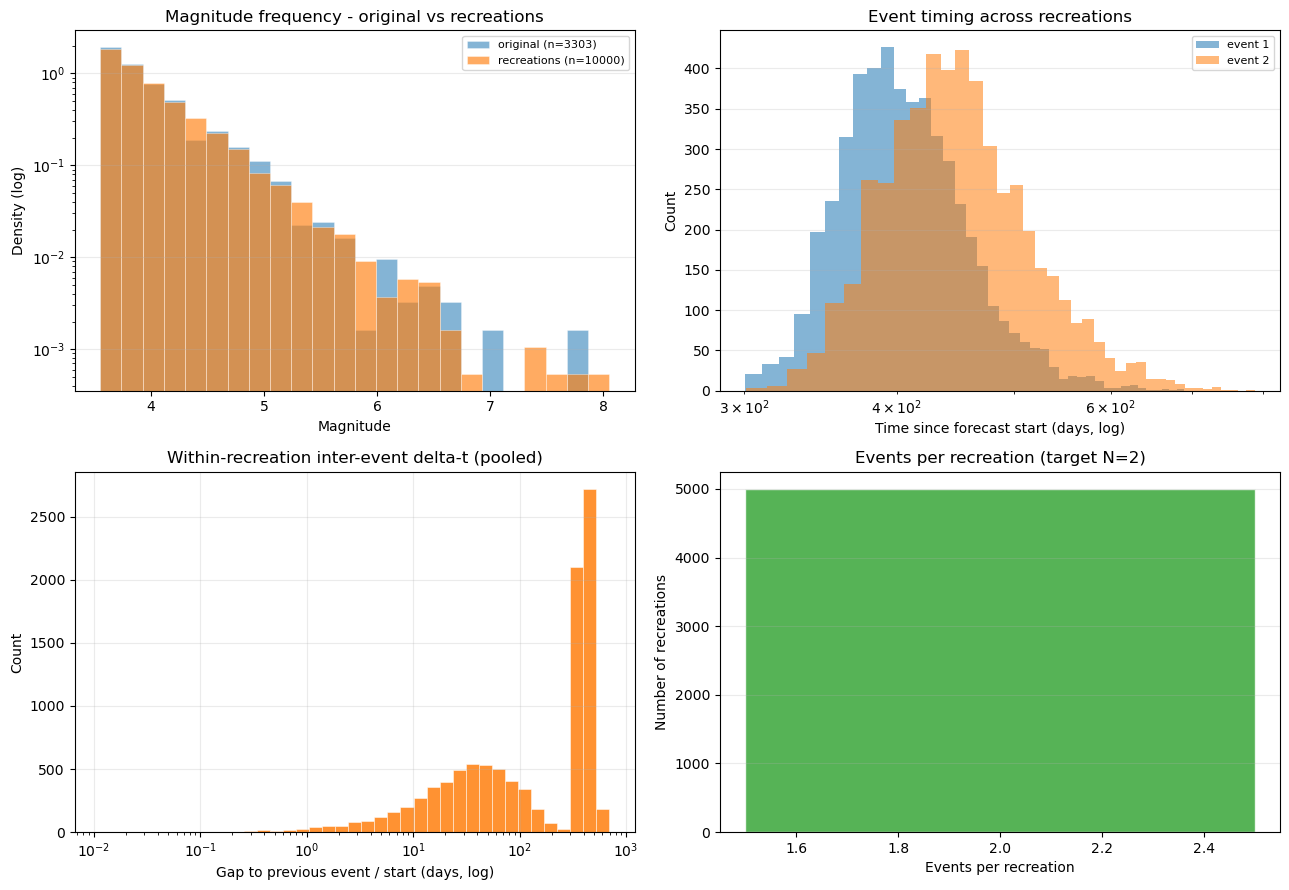

In [25]:
logging.getLogger("matplotlib").setLevel(logging.WARNING)
logging.getLogger("matplotlib.font_manager").setLevel(logging.WARNING)

t0 = pd.to_datetime(forecast_start, utc=True)

df_original = auxiliary_catalog.copy()
df_original["time"] = pd.to_datetime(df_original["time"], utc=True)
df_original["magnitude"] = pd.to_numeric(df_original["magnitude"], errors="coerce")

df_rec = simulated.copy()
df_rec["time"] = pd.to_datetime(df_rec["time"], utc=True)
df_rec["magnitude"] = pd.to_numeric(df_rec["magnitude"], errors="coerce")
df_rec = df_rec.sort_values(["recreation", "time"]).reset_index(drop=True)
df_rec["t_from_start_days"] = (df_rec["time"] - t0).dt.total_seconds() / SECONDS_PER_DAY

# Within-recreation gaps: forecast-start -> first event, then event-to-event.
dt_within = []
for _, g in df_rec.groupby("recreation"):
    tfs = g["t_from_start_days"].to_numpy()
    if len(tfs) >= 1:
        dt_within.append(tfs[0])
    if len(tfs) >= 2:
        dt_within.extend(np.diff(tfs).tolist())
dt_within = np.asarray(dt_within, dtype=float)

print(f"Recreations: {df_rec['recreation'].nunique()}, pooled events: {len(df_rec)}")
if np.any(dt_within > 0):
    q = np.quantile(dt_within[dt_within > 0], [0.05, 0.5, 0.95])
    print(f"Within-recreation gaps (days): median={q[1]:.3f}, 5-95%={q[0]:.3f}-{q[2]:.3f}")

fig, axes = plt.subplots(2, 2, figsize=(13, 9))

# (a) magnitude frequency: original vs pooled recreations
ax = axes[0, 0]
all_mag = pd.concat([df_original["magnitude"], df_rec["magnitude"]], ignore_index=True).dropna()
mag_lo = float(all_mag.min()) if len(all_mag) else mc
mag_hi = float(all_mag.max()) if len(all_mag) else mc + 2.0
mag_bins = np.linspace(mag_lo, mag_hi + 0.01, 25)
ax.hist(df_original["magnitude"].dropna(), bins=mag_bins, density=True, alpha=0.55,
        color="tab:blue", label=f"original (n={int(df_original['magnitude'].notna().sum())})",
        edgecolor="white", linewidth=0.4)
if len(df_rec):
    ax.hist(df_rec["magnitude"].dropna(), bins=mag_bins, density=True, alpha=0.65,
            color="tab:orange", label=f"recreations (n={len(df_rec)})",
            edgecolor="white", linewidth=0.4)
ax.set_yscale("log")
ax.set_xlabel("Magnitude")
ax.set_ylabel("Density (log)")
ax.set_title("Magnitude frequency - original vs recreations")
ax.legend(fontsize=8)
ax.grid(True, axis="y", alpha=0.25)

# (b) event timing relative to forecast start, split by event index
ax = axes[0, 1]
if len(df_rec):
    for idx in sorted(df_rec["event_idx"].unique()):
        vals = df_rec.loc[df_rec["event_idx"] == idx, "t_from_start_days"]
        vals = vals[vals > 0]
        if len(vals):
            ax.hist(vals, bins=40, alpha=0.55, label=f"event {int(idx) + 1}")
    ax.set_xscale("log")
ax.set_xlabel("Time since forecast start (days, log)")
ax.set_ylabel("Count")
ax.set_title("Event timing across recreations")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.25)

# (c) within-recreation inter-event delta-t (pooled)
ax = axes[1, 0]
dt_pos = dt_within[dt_within > 0]
if len(dt_pos):
    bins_dt = np.logspace(np.log10(dt_pos.min()), np.log10(dt_pos.max() * 1.01), 40)
    ax.hist(dt_pos, bins=bins_dt, color="tab:orange", alpha=0.85, edgecolor="white", linewidth=0.4)
    ax.set_xscale("log")
ax.set_xlabel("Gap to previous event / start (days, log)")
ax.set_ylabel("Count")
ax.set_title("Within-recreation inter-event delta-t (pooled)")
ax.grid(True, alpha=0.25)

# (d) events per recreation (verifies the N cap)
ax = axes[1, 1]
counts = recreations.groupby("recreation").size()
ax.hist(counts, bins=np.arange(counts.min(), counts.max() + 2) - 0.5,
        color="tab:green", alpha=0.8, edgecolor="white")
ax.set_xlabel("Events per recreation")
ax.set_ylabel("Number of recreations")
ax.set_title(f"Events per recreation (target N={N_EVENTS})")
ax.grid(True, axis="y", alpha=0.25)

fig.tight_layout()
display(fig)
plt.close(fig)


## Step 6 — Spatial check (all recreation events)

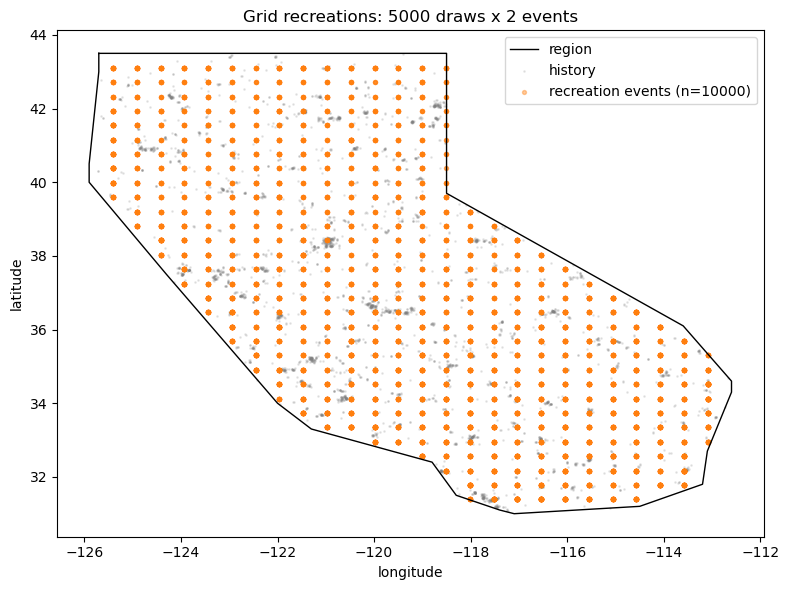

In [26]:
# Inversion sets root logging to DEBUG; suppress matplotlib font spam in this cell.
logging.getLogger("matplotlib").setLevel(logging.WARNING)
logging.getLogger("matplotlib.font_manager").setLevel(logging.WARNING)

fig, ax = plt.subplots(figsize=(8, 6))
poly_x, poly_y = zip(*[(p[1], p[0]) for p in polygon.exterior.coords])  # lon, lat for plot
ax.plot(poly_x, poly_y, "k-", lw=1, label="region")
hist = auxiliary_catalog[auxiliary_catalog["time"] < forecast_start]
ax.scatter(hist["longitude"], hist["latitude"], s=1, alpha=0.15, c="gray", label="history")
if len(simulated):
    ax.scatter(simulated["longitude"], simulated["latitude"], s=8, alpha=0.4, c="C1",
               label=f"recreation events (n={len(simulated)})")
ax.set_xlabel("longitude")
ax.set_ylabel("latitude")
ax.legend(loc="upper right")
ax.set_title(f"Grid recreations: {M_RECREATIONS} draws x {N_EVENTS} events")
fig.tight_layout()
display(fig)
plt.close(fig)


# Compute rate maps and compare

Uses the **same grid** as continuation: `continuation_prep` from
`simulate_grid_recreations` (`lat_flat` / `lon_flat`, Voronoi `ordered_cells`, `kernels`).

In [27]:
from etas import forecast_intensity


In [28]:
# Same grid nodes as continuation (GRID_POINT_DENSITY_KM2 in config cell)
lat_asses = np.asarray(continuation_prep["lat_flat"])
lon_asses = np.asarray(continuation_prep["lon_flat"])
print(
    f"Assessment grid: {len(lat_asses)} nodes "
    f"({GRID_POINT_DENSITY_KM2} pts/km², same as simulate_grid_recreations)"
)

h_t_days = auxiliary_catalog["time"].astype("datetime64[ns]").values.astype("int64") // 10**9 / SECONDS_PER_DAY
h_lat = auxiliary_catalog["latitude"].values
h_lon = auxiliary_catalog["longitude"].values
h_m = auxiliary_catalog["magnitude"].values

asses_time = h_t_days.max() + 0.02  # (0.02 a day is about half an hour)


Assessment grid: 494 nodes (0.0005 pts/km², same as simulate_grid_recreations)


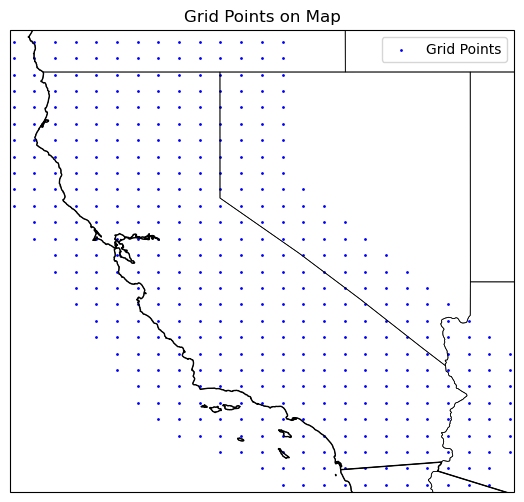

In [29]:
%matplotlib inline
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.scatter(lon_asses, lat_asses, s=1, color='blue', label='Grid Points')
plt.xlabel('Longitude')

# Plot the California outline using cartopy
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Close the plain matplotlib plot if open
plt.close() 

fig = plt.figure(figsize=(8, 6))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.coastlines(resolution='10m')
ax.add_feature(cfeature.BORDERS.with_scale('10m'))
ax.add_feature(cfeature.STATES, linewidth=0.5)

# Scatter grid points
ax.scatter(lon_asses, lat_asses, s=1, color='blue', label='Grid Points', transform=ccrs.PlateCarree())
ax.set_extent([-125, -113, 32, 43], crs=ccrs.PlateCarree())  # Rough extent for California

plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Grid Points on Map')
plt.legend()
plt.show()



In [30]:
# Voronoi cells + kernels from continuation (no second prepare_grid_inversion)
grid_prep = continuation_prep
kernels = grid_prep["kernels"]


In [31]:
# rate on all map at prediction time (kernels["f"] is r(x, y, m): degree offsets from parent)
kappa_fn = kernels["kappa"]
g_fn = kernels["g"]
f_fn = kernels["f"]
mu_fn = kernels["mu"]

local_intensity = np.zeros(len(lat_asses), dtype=float)
for k in range(len(h_lat)):
    lat_k, lon_k, m_k, t_k_days = h_lat[k], h_lon[k], h_m[k], h_t_days[k]
    dt_days = asses_time - t_k_days
    if dt_days <= 0:
        continue
    x = lon_asses - lon_k
    y = lat_asses - lat_k
    local_intensity += kappa_fn(m_k) * f_fn(x, y, m_k) * g_fn(dt_days)

rate = mu_fn(lat_asses[0], lon_asses[0]) + local_intensity


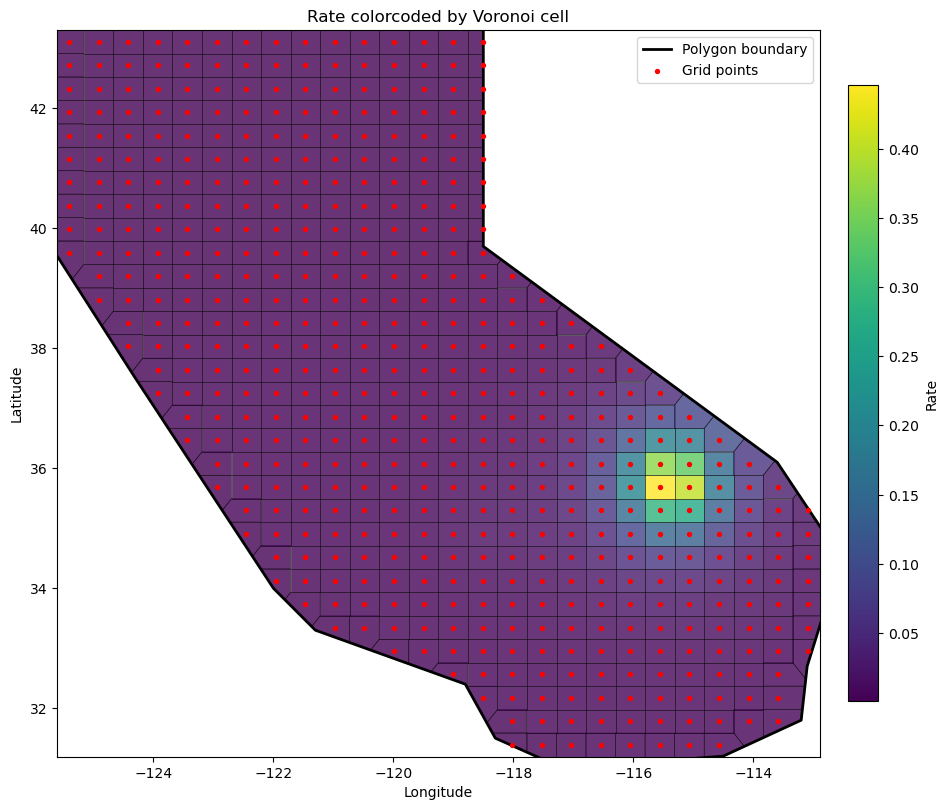

In [32]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib import colors
import numpy as np
from shapely.geometry import MultiPolygon, Polygon

# Same Voronoi cells as prepare_grid_inversion (lon/lat Shapely geometry, clipped to AOI)
ordered_cells = grid_prep["ordered_cells"]


def _polygon_parts(geom):
    if geom.is_empty:
        return
    if geom.geom_type == "Polygon":
        yield geom
    elif geom.geom_type == "MultiPolygon":
        yield from geom.geoms
    elif geom.geom_type == "GeometryCollection":
        for g in geom.geoms:
            yield from _polygon_parts(g)


fig, ax = plt.subplots(figsize=(12, 10))
norm = colors.Normalize(vmin=np.min(rate), vmax=np.max(rate))
cmap = plt.cm.viridis

for j, cell in enumerate(ordered_cells):
    color = cmap(norm(rate[j]))
    for part in _polygon_parts(cell):
        xy = np.asarray(part.exterior.coords)  # x=lon, y=lat
        ax.add_patch(
            mpatches.Polygon(
                xy,
                closed=True,
                facecolor=color,
                edgecolor="k",
                alpha=0.8,
                linewidth=0.4,
            )
        )

# Study polygon boundary (shape_coords are [lat, lon] per vertex)
poly_coords = np.asarray(polygon.exterior.coords)
lat_poly, lon_poly = poly_coords[:, 0], poly_coords[:, 1]
ax.plot(lon_poly, lat_poly, color="black", linewidth=2, label="Polygon boundary")

ax.scatter(lon_asses, lat_asses, s=8, c="red", zorder=5, label="Grid points")

# Colorbar
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, shrink=0.8, pad=0.03)
cbar.set_label('Rate')

ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('Rate colorcoded by Voronoi cell')
ax.set_aspect('equal')
ax.set_xlim(np.min(lon_asses)-0.2, np.max(lon_asses)+0.2)
ax.set_ylim(np.min(lat_asses)-0.2, np.max(lat_asses)+0.2)
ax.legend()
plt.show()



Selected 5000 events for n=1 (event_idx=0).


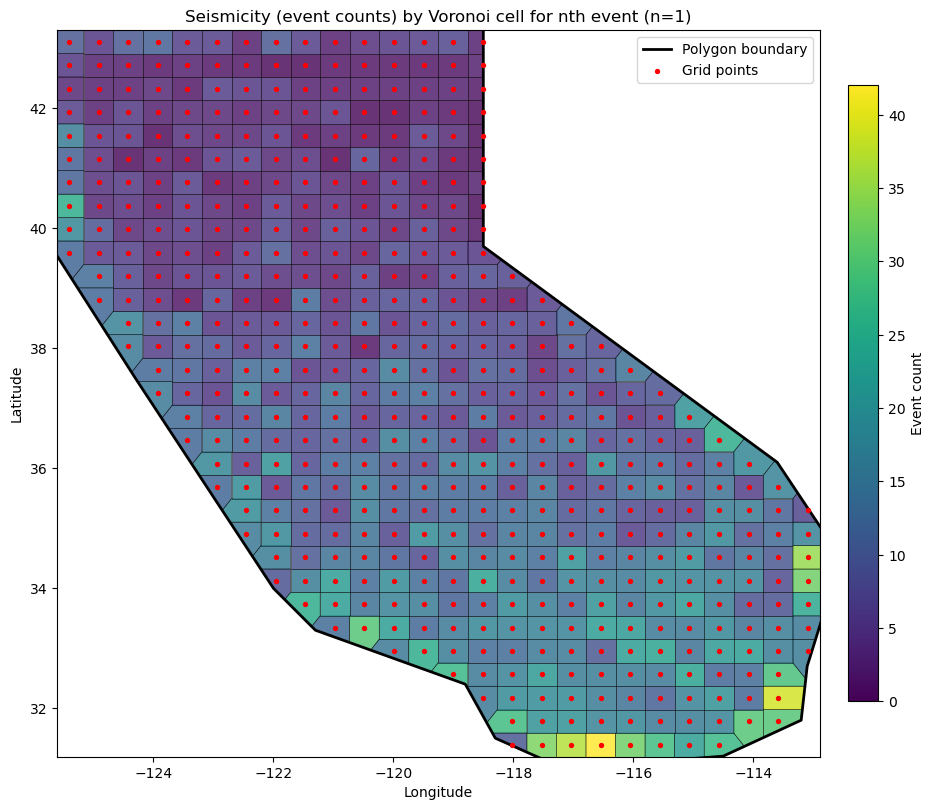

In [33]:
# Seismicity of the nth recreated event: counts per Voronoi grid cell
# n=1 means "first event" (event_idx==0).

NTH_EVENT = 1  # 1-indexed

# Select the nth event from each recreation
_nth_event_idx = int(NTH_EVENT) - 1
nth_events = recreations.loc[recreations["event_idx"] == _nth_event_idx].copy()

# Safety: ensure at most 1 event per recreation (should already hold)
if len(nth_events):
    nth_events = nth_events.sort_values(["recreation", "time"]).groupby("recreation", as_index=False).head(1)

print(f"Selected {len(nth_events)} events for n={NTH_EVENT} (event_idx={_nth_event_idx}).")

# Count events inside each Voronoi cell
from shapely.geometry import Point

counts_per_cell = np.zeros(len(ordered_cells), dtype=int)

for lon, lat in zip(nth_events["longitude"].to_numpy(), nth_events["latitude"].to_numpy()):
    p = Point(lon, lat)
    for j, cell in enumerate(ordered_cells):
        if cell.contains(p):
            counts_per_cell[j] += 1
            break

# Plot in the same format as the last plot (Voronoi cells color-coded)
fig, ax = plt.subplots(figsize=(12, 10))

vmin = int(counts_per_cell.min()) if len(counts_per_cell) else 0
vmax = int(counts_per_cell.max()) if len(counts_per_cell) else 1
if vmin == vmax:
    vmax = vmin + 1

norm = colors.Normalize(vmin=vmin, vmax=vmax)
cmap = plt.cm.viridis

for j, cell in enumerate(ordered_cells):
    color = cmap(norm(counts_per_cell[j]))
    for part in _polygon_parts(cell):
        xy = np.asarray(part.exterior.coords)  # x=lon, y=lat
        ax.add_patch(
            mpatches.Polygon(
                xy,
                closed=True,
                facecolor=color,
                edgecolor="k",
                alpha=0.8,
                linewidth=0.4,
            )
        )

# Study polygon boundary (shape_coords are [lat, lon] per vertex)
poly_coords = np.asarray(polygon.exterior.coords)
lat_poly, lon_poly = poly_coords[:, 0], poly_coords[:, 1]
ax.plot(lon_poly, lat_poly, color="black", linewidth=2, label="Polygon boundary")

ax.scatter(lon_asses, lat_asses, s=8, c="red", zorder=5, label="Grid points")

# Colorbar
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, shrink=0.8, pad=0.03)
cbar.set_label("Event count")

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title(f"Seismicity (event counts) by Voronoi cell for nth event (n={NTH_EVENT})")
ax.set_aspect("equal")
ax.set_xlim(np.min(lon_asses) - 0.2, np.max(lon_asses) + 0.2)
ax.set_ylim(np.min(lat_asses) - 0.2, np.max(lat_asses) + 0.2)
ax.legend()
plt.show()
